# Lab 1 — worked solutions

**LDSCI6253 Information Presentation & Data Visualisation** · Northeastern University London

Task 4, done four ways over: **raw → clean → visualise → insights**. Every cell here has
been run, so what you see below the code is what the code produced.

Use it to check your own work, or as the shape for a different dataset. The marks are in
stage 4 — a chart with no sentence under it is half a submission.

**The data.** `tfl-daily-cycle-hires.xlsx` sits beside this notebook: total daily hires of
the Santander Cycle Hire scheme, 30 July 2010 to 31 August 2026, 5,877 days.
Contains public sector information licensed under the
[Open Government Licence v2.0](https://www.nationalarchives.gov.uk/doc/open-government-licence/version/2/)
— Transport for London, via the [London Datastore](https://data.london.gov.uk/dataset/number-of-bicycle-hires-2r84d).

**Two things that will bite you if you skip stage 1**, and both are in the code below:
`sheet_name=0` is the *metadata* sheet, and pointing `read_excel` at the URL returns
HTTP 403 — the Datastore refuses the user agent pandas sends. Download the file; read it
from disk.

## Stage 1 · Raw

Look at the file before believing anything about it.

In [1]:
import pandas as pd

# Download the .xlsx from the link on the last slide and put it
# beside your notebook. Pointing pandas at the URL gives 403.
path = "tfl-daily-cycle-hires.xlsx"

print(pd.ExcelFile(path).sheet_names)
# ['Metadata', 'Data']   <- sheet 0 is NOT the data

raw = pd.read_excel(path, sheet_name="Data", header=None)
print(raw.shape)          # (5883, 16)
print(raw.iloc[:7, 1:3])  # notes and totals sit above the series

['Metadata', 'Data']
(5883, 16)
                                                   1                        2
0                                                NaN                      NaN
1  Please note that from 01 August 2017 due to de...                      NaN
2                                                NaN                      NaN
3                                  Daily Grand Total                154053134
4                                                NaN                      NaN
5                                                Day  Number of Bicycle Hires
6                                2010-07-30 00:00:00                     6897


Three things that output tells us, none of which were guessable:

1. The workbook has **two sheets**, and `Data` is the second. `sheet_name=0` would have
   read twenty-nine rows of description.
2. The sheet is **5,883 × 16** — far wider than a daily series needs, because day, month
   and year blocks sit side by side.
3. There is a notes paragraph and three **grand totals above the header**, so the header
   is on row 6, not row 1.

## Stage 2 · Clean

One row per day, a real date, a real number.

In [2]:
df = pd.read_excel(path, sheet_name="Data", skiprows=5,
                   usecols=[1, 2], names=["date", "hires"])

df = df.dropna()
df["date"] = pd.to_datetime(df["date"])
df["hires"] = pd.to_numeric(df["hires"])

# Check against the total the file states about itself:
print(len(df), int(df["hires"].sum()))
# 5877 154053134   <- matches the sheet’s own Grand Total

5877 154053134


Every argument there is a decision you should be able to defend: the sheet by **name**
rather than position, skip the five rows above the header, take two of the sixteen columns,
name them.

The `print` is the habit worth stealing. The file states its own grand total, so a clean
read can be checked against it — **154,053,134**. If your sum does not match, your cleaning
is wrong, and you have found out in one line instead of in the marking.

## Stage 3 · Visualise

One question, one chart.

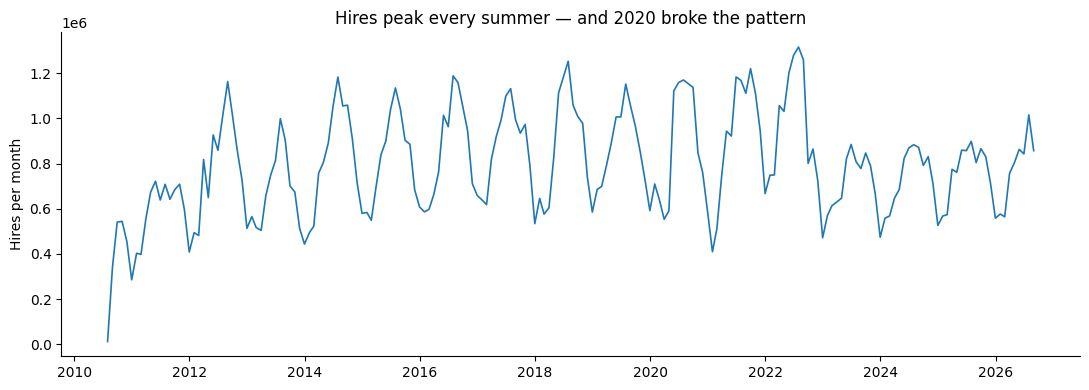

In [3]:
import matplotlib.pyplot as plt

monthly = df.set_index("date")["hires"].resample("ME").sum()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly.index, monthly.values, linewidth=1.2)
ax.set_title("Hires peak every summer — and 2020 broke the pattern")
ax.set_ylabel("Hires per month")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Daily is too noisy to read, so resample to monthly totals first. That is an editorial
choice and it belongs in your write-up.

The title is the only line with an opinion in it, and that is the habit: **say the finding,
not the subject**. "Hires per month" is the axis label. "Hires peak every summer — and 2020
broke the pattern" is the chart.

## Stage 4 · Insights

Compute them. Do not eyeball them.

In [4]:
# Stage 4 · Insights. Compute them; do not eyeball them.
by_month = df.groupby(df["date"].dt.month)["hires"].mean()
print("July mean daily:     %d" % round(by_month[7]))
print("December mean daily: %d" % round(by_month[12]))
print("summer:winter        %.1fx" % (by_month[7] / by_month[12]))

apr = {y: df[(df["date"].dt.year == y) & (df["date"].dt.month == 4)]["hires"].sum()
       for y in (2019, 2020)}
print("April 2019 / 2020:   %d / %d  (%+.0f%%)"
      % (apr[2019], apr[2020], (apr[2020] / apr[2019] - 1) * 100))

annual = df.groupby(df["date"].dt.year)["hires"].sum()
print("2022 / 2023:         %.2fM / %.2fM  (%+.0f%%)"
      % (annual[2022] / 1e6, annual[2023] / 1e6,
         (annual[2023] / annual[2022] - 1) * 100))

weekday = df.groupby(df["date"].dt.dayofweek < 5)["hires"].mean()
# round, not truncate: %d on 22997.6 prints 22997 and the slides say 22,998
print("weekend / weekday:   %d / %d" % (round(weekday[False]), round(weekday[True])))

July mean daily:     34212
December mean daily: 17132
summer:winter        2.0x
April 2019 / 2020:   890148 / 591294  (-34%)
2022 / 2023:         11.51M / 8.53M  (-26%)
weekend / weekday:   22998 / 27500


In [5]:
# The two traps, shown rather than described.
monthly = df.set_index("date")["hires"].resample("ME").sum()
print("lowest month in the file:", monthly.idxmin().strftime("%B %Y"),
      int(monthly.min()), "<- two days of trading: the scheme opened on 30 July")
after = monthly[monthly.index.year >= 2012]
print("lowest month from 2012:  ", after.idxmin().strftime("%B %Y"),
      int(after.min()), "<- a seasonal floor AND a lockdown, at once")

lowest month in the file: July 2010 12461 <- two days of trading: the scheme opened on 30 July
lowest month from 2012:   January 2021 409887 <- a seasonal floor AND a lockdown, at once


### The paragraph this is all for

> Santander Cycle hires follow a hard annual cycle: July averages **34,212** hires a day
> against December's **17,132**, a factor of **two**. Two events break the pattern. April
> 2020 fell **34%** below April 2019 (591,294 against 890,148) — the first lockdown — and
> annual hires dropped **26%** between 2022 and 2023, from 11.51M to 8.53M. The second is
> the more interesting, because **this dataset cannot explain it**: it records hires and
> nothing else, so fares, dock changes, e-bikes and weather are all outside it. Naming the
> gap is the finding; inventing a cause would not be. The series also contradicts the
> obvious guess about who uses it — weekdays average **27,500** hires a day against
> weekends' **22,998**, so this is commuting infrastructure, not a leisure amenity.

### Two traps, both of which look like findings

- **The lowest month in the file is July 2010** at 12,461 hires. Not a collapse — two days
  of trading, because the scheme opened on the 30th.
- **The lowest month after that is January 2021.** January is the seasonal floor *anyway*,
  and that was also a lockdown. Two causes, one number: do not attribute it to either alone.

Both are why the annual chart in the slides leaves out 2010 and 2026. They are part years,
and drawing them invents two cliffs that are calendar artefacts rather than cycling.

### What to submit

1. Your notebook, **with the outputs visible** — run every cell, then save, then submit.
   A notebook with cleared outputs reads as code that has never run.
2. A short description: what the data is, where it came from, what you did.
3. Your Task 2 critique on Canvas, with the URL to the original.

On Canvas by the **Monday after the lab, 23:59**.